<a href="https://colab.research.google.com/github/Namesakenberg/BrickByBrickML/blob/main/missing_value_imputation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [272]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [273]:
pd.set_option('display.max_rows',None)
pd.set_option('display.max_columns',None)
pd.set_option('display.max_colwidth',None)

In [274]:
df=pd.read_csv('/content/gurgaon_properties_outlier_treated.csv')

In [275]:
df.head()

,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,floorNum,facing,agePossession,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score,area_room_ratio
0,flat,signature global park 4,sector 36,0.82,7586.0,1081.0,Super Built up area 1081(100.43 sq.m.)Carpet area: 650 sq.ft. (60.39 sq.m.),3.0,2.0,2,2.0,NaN,New Property,1081.0,NaN,650.0,0.0,0.0,0.0,0.0,0.0,0.0,8.0,360.333333
1,flat,smart world gems,sector 89,0.95,8597.0,1105.0,Carpet area: 1103 (102.47 sq.m.),2.0,2.0,2,4.0,NaN,New Property,NaN,NaN,1103.0,1.0,1.0,0.0,0.0,0.0,0.0,38.0,552.500000
2,flat,breez global hill view,sohna road,0.32,5470.0,585.0,Built Up area: 1000 (92.9 sq.m.)Carpet area: 585 sq.ft. (54.35 sq.m.),2.0,2.0,1,17.0,NaN,New Property,NaN,1000.0,585.0,0.0,0.0,0.0,0.0,0.0,0.0,49.0,292.500000
3,flat,bestech park view sanskruti,sector 92,1.60,8020.0,1995.0,Super Built up area 1995(185.34 sq.m.)Built Up area: 1615 sq.ft. (150.04 sq.m.)Carpet area: 1476 sq.ft. (137.12 sq.m.),3.0,4.0,3+,10.0,North-West,Relatively New,1995.0,1615.0,1476.0,0.0,1.0,0.0,0.0,1.0,1.0,174.0,665.000000
4,flat,suncity avenue,sector 102,0.48,9023.0,532.0,Super Built up area 632(58.71 sq.m.)Carpet area: 532 sq.ft. (49.42 sq.m.),2.0,2.0,1,5.0,North-East,Relatively New,632.0,NaN,532.0,0.0,0.0,1.0,0.0,0.0,0.0,159.0,266.000000


In [276]:
df.shape

(3555, 24)

In [277]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3555 entries, 0 to 3554
Data columns (total 24 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   property_type        3555 non-null   object 
 1   society              3554 non-null   object 
 2   sector               3555 non-null   object 
 3   price                3555 non-null   float64
 4   price_per_sqft       3555 non-null   float64
 5   area                 3555 non-null   float64
 6   areaWithType         3555 non-null   object 
 7   bedRoom              3555 non-null   float64
 8   bathroom             3555 non-null   float64
 9   balcony              3555 non-null   object 
 10  floorNum             3538 non-null   float64
 11  facing               2544 non-null   object 
 12  agePossession        3555 non-null   object 
 13  super_built_up_area  1875 non-null   float64
 14  built_up_area        1587 non-null   float64
 15  carpet_area          1840 non-null   f

In [278]:
df.isnull().sum()

,0
property_type,0
society,1
sector,0
price,0
price_per_sqft,0
area,0
areaWithType,0
bedRoom,0
bathroom,0
balcony,0


In [279]:
# the most important column here is the builtup area

<Axes: xlabel='built_up_area', ylabel='super_built_up_area'>

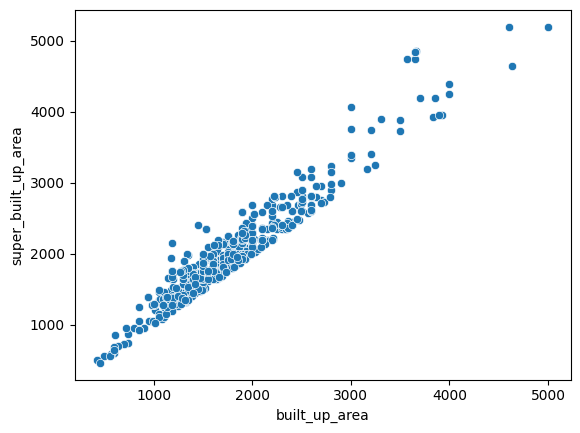

In [280]:
# relation between the builtup area and super builtup area

sns.scatterplot(x=df['built_up_area'] , y=df['super_built_up_area'])

In [281]:
# a strong linear relation exists , and its quite obvious

<Axes: xlabel='built_up_area', ylabel='carpet_area'>

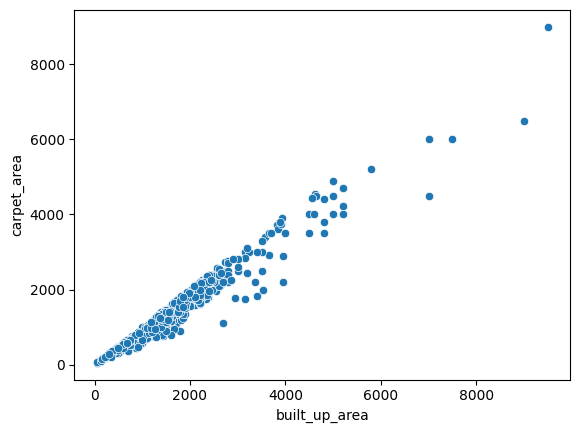

In [282]:
# relation between the builtup area and carpet area

sns.scatterplot(x=df['built_up_area'] , y=df['carpet_area'])

In [283]:
# rows where all three areas are not given

df[(df['super_built_up_area'].isnull()) & (df['built_up_area'].isnull()) & (df['carpet_area'].isnull())].shape[0]

0

In [284]:
# rows where all three areas are given
all_present_df = df[~((df['super_built_up_area'].isnull()) | (df['built_up_area'].isnull()) | (df['carpet_area'].isnull()))]

In [285]:
all_present_df.shape

(531, 24)

In [286]:
# ratio between super builtup and builtup area
ratio_superbuiltup_builtup = (all_present_df['super_built_up_area'] / all_present_df['built_up_area']).median()

ratio_superbuiltup_builtup

1.105263157894737

In [287]:
# ratio between carpet area and  buildup
ratio_superbuiltup_carpet = (all_present_df['carpet_area'] / all_present_df['built_up_area']).median()

ratio_superbuiltup_carpet

0.9

In [288]:
# data where the super builtup and carpet area are given but the buildup area is not given

built_up_absent = df[~(df['super_built_up_area'].isnull()) & (df['built_up_area'].isnull()) & ~(df['carpet_area'].isnull())]

In [289]:
built_up_absent.head()

,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,floorNum,facing,agePossession,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score,area_room_ratio
0,flat,signature global park 4,sector 36,0.82,7586.0,1081.0,Super Built up area 1081(100.43 sq.m.)Carpet area: 650 sq.ft. (60.39 sq.m.),3.0,2.0,2,2.0,NaN,New Property,1081.0,NaN,650.0,0.0,0.0,0.0,0.0,0.0,0.0,8.0,360.333333
4,flat,suncity avenue,sector 102,0.48,9023.0,532.0,Super Built up area 632(58.71 sq.m.)Carpet area: 532 sq.ft. (49.42 sq.m.),2.0,2.0,1,5.0,North-East,Relatively New,632.0,NaN,532.0,0.0,0.0,1.0,0.0,0.0,0.0,159.0,266.000000
38,flat,corona optus,sector 37,1.25,7176.0,1742.0,Super Built up area 1735(161.19 sq.m.)Carpet area: 1400 sq.ft. (130.06 sq.m.),3.0,3.0,3,2.0,North-West,Relatively New,1735.0,NaN,1400.0,1.0,0.0,0.0,0.0,0.0,0.0,49.0,580.666667
40,flat,m3m merlin,sector 67,2.80,13679.0,2047.0,Super Built up area 2047(190.17 sq.m.)Carpet area: 1880 sq.ft. (174.66 sq.m.),3.0,3.0,3,5.0,North-East,Moderately Old,2047.0,NaN,1880.0,0.0,1.0,0.0,0.0,0.0,2.0,26.0,682.333333
45,flat,smart world orchard,sector 61,2.10,13752.0,1527.0,Super Built up area 1549(143.91 sq.m.)Carpet area: 1500 sq.ft. (139.35 sq.m.),3.0,2.0,3,3.0,South,Under Construction,1549.0,NaN,1500.0,0.0,0.0,0.0,0.0,0.0,0.0,146.0,509.000000


In [290]:
# buildup = super buildup / 1.1
# buildup = carpet/0.9

In [291]:
built_up_absent['built_up_area'].fillna(round(((built_up_absent['super_built_up_area']/1.105) + (built_up_absent['carpet_area']/0.9))/2),inplace=True)

/tmp/ipython-input-291-1389574077.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  built_up_absent['built_up_area'].fillna(round(((built_up_absent['super_built_up_area']/1.105) + (built_up_absent['carpet_area']/0.9))/2),inplace=True)
/tmp/ipython-input-291-1389574077.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  built_up_absent['built

In [292]:
df.update(built_up_absent)

In [293]:
df.isnull().sum()

,0
property_type,0
society,1
sector,0
price,0
price_per_sqft,0
area,0
areaWithType,0
bedRoom,0
bathroom,0
balcony,0


In [294]:
only_super = df[~(df['super_built_up_area'].isnull()) & (df['built_up_area'].isnull()) & (df['carpet_area'].isnull())]  # data where only super built up area is given
only_super['built_up_area'] .fillna((only_super['super_built_up_area']/1.105),inplace=True)

/tmp/ipython-input-294-667055900.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  only_super['built_up_area'] .fillna((only_super['super_built_up_area']/1.105),inplace=True)
/tmp/ipython-input-294-667055900.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  only_super['built_up_area'] .fillna((only_super['super_built_up_area']/1.105),inpla

In [295]:
only_super.shape

(875, 24)

In [296]:
df.update(only_super)

In [297]:
df.isnull().sum()

,0
property_type,0
society,1
sector,0
price,0
price_per_sqft,0
area,0
areaWithType,0
bedRoom,0
bathroom,0
balcony,0


In [298]:
carpet_only = df[(df['super_built_up_area'].isnull())&(df['built_up_area'].isnull())&~(df['carpet_area'].isnull())]    # data where only carpet area is given
carpet_only['built_up_area'].fillna(round(carpet_only['carpet_area']/0.9) ,inplace=True)

/tmp/ipython-input-298-3525098798.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  carpet_only['built_up_area'].fillna(round(carpet_only['carpet_area']/0.9) ,inplace=True)
/tmp/ipython-input-298-3525098798.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  carpet_only['built_up_area'].fillna(round(carpet_only['carpet_area']/0.9) ,inplace=T

In [299]:
df.update(carpet_only)

In [300]:
df.isnull().sum()

,0
property_type,0
society,1
sector,0
price,0
price_per_sqft,0
area,0
areaWithType,0
bedRoom,0
bathroom,0
balcony,0


<Axes: xlabel='built_up_area', ylabel='price'>

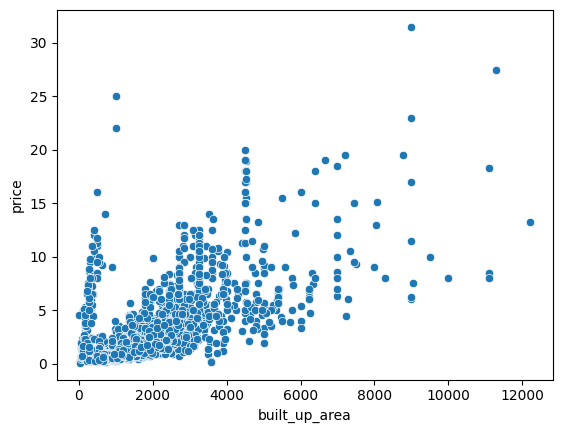

In [301]:
sns.scatterplot(x=df['built_up_area'] , y =df['price'])

In [302]:
# in the graph the vertical points above 0 shows that there is some anomaly in the data i.e the flats where area is lesser than 1000 sqft stil the prices are above 5 crores

In [303]:
anomaly_df = df[(df['built_up_area'] < 1000 )& (df['price']>2.5)]

In [304]:
anomaly_df['built_up_area'] = anomaly_df['area']
df.update(anomaly_df)

/tmp/ipython-input-304-3907302132.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  anomaly_df['built_up_area'] = anomaly_df['area']


<Axes: xlabel='built_up_area', ylabel='price'>

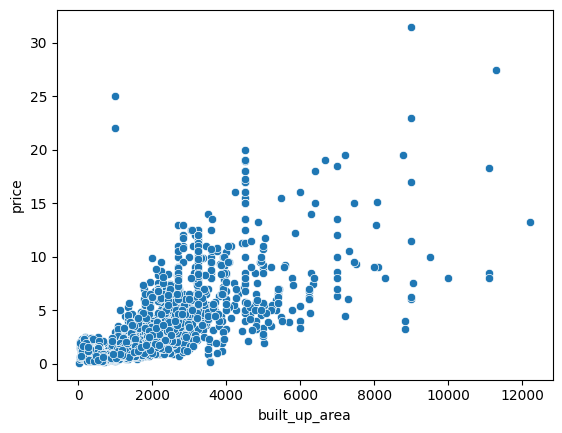

In [305]:
sns.scatterplot(x=df['built_up_area'] , y =df['price'])

In [306]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3555 entries, 0 to 3554
Data columns (total 24 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   property_type        3555 non-null   object 
 1   society              3554 non-null   object 
 2   sector               3555 non-null   object 
 3   price                3555 non-null   float64
 4   price_per_sqft       3555 non-null   float64
 5   area                 3555 non-null   float64
 6   areaWithType         3555 non-null   object 
 7   bedRoom              3555 non-null   float64
 8   bathroom             3555 non-null   float64
 9   balcony              3555 non-null   object 
 10  floorNum             3538 non-null   float64
 11  facing               2544 non-null   object 
 12  agePossession        3555 non-null   object 
 13  super_built_up_area  1875 non-null   float64
 14  built_up_area        3555 non-null   float64
 15  carpet_area          1840 non-null   f

In [307]:
df.drop(columns=['area','areaWithType','super_built_up_area','carpet_area','area_room_ratio'],inplace=True)
# drop all the area related columns except builtup area

In [308]:
df.head()

,property_type,society,sector,price,price_per_sqft,bedRoom,bathroom,balcony,floorNum,facing,agePossession,built_up_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
0,flat,signature global park 4,sector 36,0.82,7586.0,3.0,2.0,2,2.0,NaN,New Property,850.0,0.0,0.0,0.0,0.0,0.0,0.0,8.0
1,flat,smart world gems,sector 89,0.95,8597.0,2.0,2.0,2,4.0,NaN,New Property,1226.0,1.0,1.0,0.0,0.0,0.0,0.0,38.0
2,flat,breez global hill view,sohna road,0.32,5470.0,2.0,2.0,1,17.0,NaN,New Property,1000.0,0.0,0.0,0.0,0.0,0.0,0.0,49.0
3,flat,bestech park view sanskruti,sector 92,1.60,8020.0,3.0,4.0,3+,10.0,North-West,Relatively New,1615.0,0.0,1.0,0.0,0.0,1.0,1.0,174.0
4,flat,suncity avenue,sector 102,0.48,9023.0,2.0,2.0,1,5.0,North-East,Relatively New,582.0,0.0,0.0,1.0,0.0,0.0,0.0,159.0


In [309]:
df.isnull().sum()

,0
property_type,0
society,1
sector,0
price,0
price_per_sqft,0
bedRoom,0
bathroom,0
balcony,0
floorNum,17
facing,1011


# Floor Num

In [310]:
df['floorNum'].isnull().sum()

np.int64(17)

In [311]:
df[df['floorNum'].isnull()]

,property_type,society,sector,price,price_per_sqft,bedRoom,bathroom,balcony,floorNum,facing,agePossession,built_up_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
500,house,independent,sector 4,0.65,11111.0,4.0,2.0,2,NaN,NaN,Moderately Old,585.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
767,house,independent,sector 7,6.50,15046.0,3.0,2.0,3+,NaN,NaN,Old Property,4320.0,0.0,0.0,0.0,0.0,0.0,0.0,9.0
1294,house,independent,sector 3,1.50,10288.0,3.0,3.0,0,NaN,NaN,Old Property,210.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1452,house,vipul tatvam villa,sector 48,8.50,26235.0,4.0,4.0,1,NaN,NaN,Relatively New,3240.0,0.0,0.0,0.0,0.0,0.0,0.0,21.0
1465,house,ansal sushant lok plots,sector 43,3.30,26570.0,1.0,1.0,0,NaN,NaN,Under Construction,1242.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1946,house,jacob pura,sector 12,0.35,9722.0,2.0,1.0,0,NaN,NaN,Old Property,360.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2048,house,vipul tatvam villa,sector 48,8.50,26235.0,4.0,4.0,2,NaN,East,Moderately Old,3240.0,0.0,1.0,1.0,1.0,0.0,0.0,88.0
2157,house,independent,sector 4,4.12,8889.0,2.0,1.0,3+,NaN,NaN,Moderately Old,4635.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2271,house,emaar mgf marbella,sector 66,9.00,21251.0,4.0,4.0,3+,NaN,South-West,Relatively New,5200.0,0.0,1.0,1.0,1.0,0.0,1.0,114.0
2439,house,dlf new town heights,sector 86,2.47,7719.0,4.0,4.0,3+,NaN,West,Moderately Old,2800.0,0.0,1.0,0.0,1.0,0.0,1.0,130.0


In [312]:
# most of these are houses , so replace the floor number with the median of all the floors of houses

df[df['property_type']=='house']['floorNum'].median()

2.0

In [313]:
df['floorNum'].fillna(2.0, inplace=True)

/tmp/ipython-input-313-721975971.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['floorNum'].fillna(2.0, inplace=True)


In [314]:
df.isnull().sum()

,0
property_type,0
society,1
sector,0
price,0
price_per_sqft,0
bedRoom,0
bathroom,0
balcony,0
floorNum,0
facing,1011


# Facing

In [315]:
df['facing'].isnull().sum()

np.int64(1011)

<Axes: ylabel='count'>

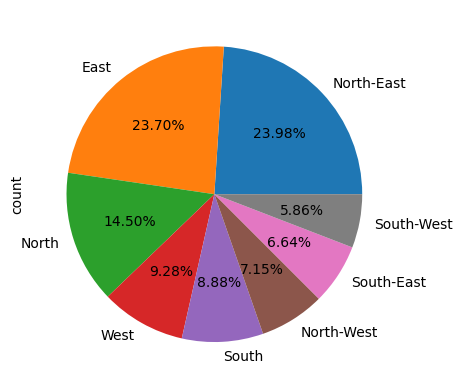

In [316]:
df['facing'].value_counts().plot(kind='pie',autopct='%0.2f%%')

In [317]:
# there are 1011 values and since its a categorical column it is even difficult to impute
# since the column is not much significant
df.drop(columns=['facing'],inplace = True)

In [318]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3555 entries, 0 to 3554
Data columns (total 18 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   property_type    3555 non-null   object 
 1   society          3554 non-null   object 
 2   sector           3555 non-null   object 
 3   price            3555 non-null   float64
 4   price_per_sqft   3555 non-null   float64
 5   bedRoom          3555 non-null   float64
 6   bathroom         3555 non-null   float64
 7   balcony          3555 non-null   object 
 8   floorNum         3555 non-null   float64
 9   agePossession    3555 non-null   object 
 10  built_up_area    3555 non-null   float64
 11  study room       3555 non-null   float64
 12  servant room     3555 non-null   float64
 13  store room       3555 non-null   float64
 14  pooja room       3555 non-null   float64
 15  others           3555 non-null   float64
 16  furnishing_type  3555 non-null   float64
 17  luxury_score  

In [319]:
df[df['society'].isnull()]

,property_type,society,sector,price,price_per_sqft,bedRoom,bathroom,balcony,floorNum,agePossession,built_up_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
2536,flat,NaN,sector 78,0.6,3692.0,2.0,2.0,0,2.0,Under Construction,1625.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [320]:
df.drop(index=[2536],inplace=True)

In [321]:
df.isnull().sum()

,0
property_type,0
society,0
sector,0
price,0
price_per_sqft,0
bedRoom,0
bathroom,0
balcony,0
floorNum,0
agePossession,0


In [322]:
# the age possesion column still has null values under the section undefined

## age_possession

In [323]:
df['agePossession'].value_counts()

,count
agePossession,
Relatively New,1605
New Property,557
Moderately Old,545
Old Property,293
Undefined,291
Under Construction,263


In [324]:
df[df['agePossession']=='Undefined'].sample(5)

,property_type,society,sector,price,price_per_sqft,bedRoom,bathroom,balcony,floorNum,agePossession,built_up_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
908,flat,ashiana anmol,sector 33,1.10,8627.0,2.0,2.0,2,4.0,Undefined,1275.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1896,house,independent,sector 17,3.50,24306.0,2.0,6.0,3+,3.0,Undefined,1440.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1366,flat,smartworld one dxp,sector 113,2.00,11074.0,3.0,3.0,3,12.0,Undefined,1806.0,0.0,0.0,0.0,0.0,0.0,0.0,70.0
1295,flat,dlf the grove,sector 54,5.70,41245.0,3.0,3.0,3,1.0,Undefined,1382.0,0.0,0.0,0.0,0.0,0.0,0.0,46.0
2391,house,independent,sector 105,0.38,8444.0,2.0,2.0,2,1.0,Undefined,56.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [325]:
def mode_imputation(row):
  if row['agePossession']=='Undefined':
    mode_value=df[(df['sector']==row['sector']) & (df['property_type']==row['property_type'])]['agePossession'].mode()
    if not mode_value.empty:
      return mode_value.iloc[0]
    else:
      return np.nan
  else:
    return row['agePossession']

In [326]:
df['agePossession']= df.apply(mode_imputation,axis=1)

In [327]:
df['agePossession'].value_counts()

,count
agePossession,
Relatively New,1715
New Property,598
Moderately Old,585
Old Property,324
Under Construction,277
Undefined,55


In [328]:
def mode_based_imputation2(row):
    if row['agePossession'] == 'Undefined':
        mode_value = df[(df['sector'] == row['sector'])]['agePossession'].mode()
        # If mode_value is empty (no mode found), return NaN, otherwise return the mode
        if not mode_value.empty:
            return mode_value.iloc[0]
        else:
            return np.nan
    else:
        return row['agePossession']

In [329]:
df['agePossession'] = df.apply(mode_based_imputation2,axis=1)

In [330]:
df['agePossession'].value_counts()

,count
agePossession,
Relatively New,1730
New Property,599
Moderately Old,592
Old Property,327
Under Construction,277
Undefined,29


In [331]:
def mode_based_imputation3(row):
    if row['agePossession'] == 'Undefined':
        mode_value = df[(df['property_type'] == row['property_type'])]['agePossession'].mode()
        # If mode_value is empty (no mode found), return NaN, otherwise return the mode
        if not mode_value.empty:
            return mode_value.iloc[0]
        else:
            return np.nan
    else:
        return row['agePossession']

In [332]:
df.isnull().sum()

,0
property_type,0
society,0
sector,0
price,0
price_per_sqft,0
bedRoom,0
bathroom,0
balcony,0
floorNum,0
agePossession,0


In [334]:
df.shape

(3554, 18)

In [335]:
df.to_csv('gurgaon_properties_missing_value_imputation.csv',index=False)